## 1. Setup & Load Data from S3
Loads the raw Grad Café JSON from S3 into a DataFrame using boto3.

In [4]:
!pip install --quiet scipy matplotlib pandas numpy boto3 reportlab

In [13]:
"""boto3 logic"""
from pathlib import Path
import boto3
import json
import re
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

DEFAULT_BUCKET = "grad-cafe-rps"
DEFAULT_KEY = "applicant_data.json"
FIXED_KEY = "applicant_data_fixed.json"   # where the corrected raw file will live in S3

def get_s3_client(region_name: str = "us-east-1"):
    """builds boto3 s3 client"""
    session = boto3.session.Session()
    return session.client("s3", region_name=region_name)

def download_applicant_data(
        bucket: str = DEFAULT_BUCKET,
        key: str = DEFAULT_KEY,
        destination: str = "applicant_data_SM.json",
) -> Path:
    """Download the Grad Cafe applicant dataset from S3."""
    s3_client = get_s3_client()
    dest_path = Path(destination)
    s3_client.download_file(bucket, key, str(dest_path))
    return dest_path

def verify_download(path: Path) -> bool:
    """Confirm the downloaded file exists"""
    return path.exists() and path.stat().st_size > 0

# --- Step 1: download the enriched-but-broken-status file from S3, as before ---
enriched_path = download_applicant_data()
assert verify_download(enriched_path), "Download failed or file is empty"

with open(enriched_path) as f:
    enriched = json.load(f)

# --- Step 2: load the true original scrape (has real status + embedded date) ---
with open("applicant_data.json") as f:
    original = json.load(f)

assert len(original) == len(enriched), "Row counts don't match -- don't merge blindly"

# --- Step 3: repair status using the original file, matched by url ---
status_by_url = {row["url"]: row["status"] for row in original}

fixed_rows = []
for row in enriched:
    row = dict(row)
    row["status"] = status_by_url.get(row["url"], row["status"])
    fixed_rows.append(row)

df = pd.DataFrame(fixed_rows)
print(df["status"].value_counts().head(10))
print(f"\nLoaded {len(df)} rows with the real status column restored")

# --- Step 4: save corrected file locally, then upload to S3 for future use ---
with open(FIXED_KEY, "w") as f:
    json.dump(fixed_rows, f)

s3_client = get_s3_client()
s3_client.upload_file(FIXED_KEY, DEFAULT_BUCKET, FIXED_KEY)
print(f"Uploaded corrected raw data to s3://{DEFAULT_BUCKET}/{FIXED_KEY}")

BUCKET_NAME = DEFAULT_BUCKET
RAW_KEY = FIXED_KEY
CLEANED_KEY = "cleaned_gradcafe.json"

status
Rejected on Mar 19    157
Rejected on Apr 01    130
Rejected on Mar 24    126
Rejected on Mar 18    114
Rejected on Mar 23    111
Rejected on Apr 02    109
Rejected on Mar 25    105
Accepted on Mar 18    100
Rejected on Mar 20     99
Rejected on Mar 26     98
Name: count, dtype: int64

Loaded 5000 rows with the real status column restored
Uploaded corrected raw data to s3://grad-cafe-rps/applicant_data_fixed.json


## 2. Raw Data Inspection & Missingness Reporting
Preserves a raw copy (`raw_df`), inspects shape/columns/dtypes, and summarizes missing values.

In [14]:
raw_df = df.copy()

display(raw_df.head())


,university,program,date,status,url,listing,comments,raw_text,gpa,gre,gre_v,gre_aw,degree_type,international,year,term,llm_generated_program,llm_generated_university
0,"Islamic Azad University, Fars Science & Resear...",Business Administration Masters,"Jun 07, 2026",Accepted on Jun 07,https://www.thegradcafe.com/result/1020324,"Islamic Azad University, Fars Science & Resear...",Business Administration,The GradCafe Business Administration - Islamic...,NaN,NaN,NaN,NaN,Masters,Domestic,2026.0,Fall 2026,None,None
1,Isfahan University of Technology,Pure Mathematics Masters,"Jun 07, 2026",Accepted on Jun 07,https://www.thegradcafe.com/result/1020323,Isfahan University of Technology Pure Mathemat...,Pure Mathematics,The GradCafe Pure Mathematics - Isfahan Univer...,NaN,NaN,NaN,NaN,Masters,International,2026.0,Fall 2026,None,None
2,Tabriz University,Manufacturing Engineering Masters,"Jun 07, 2026",Accepted on Jun 07,https://www.thegradcafe.com/result/1020322,Tabriz University Manufacturing Engineering Ma...,Manufacturing Engineering,The GradCafe Manufacturing Engineering - Tabri...,3.6,NaN,NaN,NaN,Masters,International,2026.0,Fall 2026,None,None
3,Rivers State University of Science and Technology,Naval Architecture and Marine Engineering Masters,"Jun 07, 2026",Wait listed on Jun 07,https://www.thegradcafe.com/result/1020321,Rivers State University of Science and Technol...,Naval Architecture and Marine Engineering,The GradCafe Naval Architecture and Marine Eng...,2.3,NaN,NaN,NaN,Masters,International,2026.0,Fall 2026,None,None
4,University of Birmingham,Physics PhD,"Jun 06, 2026",Rejected on Jun 02,https://www.thegradcafe.com/result/1020320,"University of Birmingham Physics PhD Jun 06, 2...",Physics,The GradCafe Physics - University of Birmingha...,NaN,NaN,NaN,NaN,PhD,Domestic,2026.0,Fall 2026,None,None


In [16]:
# Basic structure of the raw dataset
n_rows, n_cols = raw_df.shape
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")
print(f"Column names: {list(raw_df.columns)}")
print("\nDatatypes:")
print(raw_df.dtypes)

Number of rows: 5000
Number of columns: 18
Column names: ['university', 'program', 'date', 'status', 'url', 'listing', 'comments', 'raw_text', 'gpa', 'gre', 'gre_v', 'gre_aw', 'degree_type', 'international', 'year', 'term', 'llm_generated_program', 'llm_generated_university']

Datatypes:
university                   object
program                      object
date                         object
status                       object
url                          object
listing                      object
comments                     object
raw_text                     object
gpa                         float64
gre                         float64
gre_v                       float64
gre_aw                      float64
degree_type                  object
international                object
year                        float64
term                         object
llm_generated_program        object
llm_generated_university     object
dtype: object


In [17]:
# Missingness summary table
missing_counts = raw_df.isna().sum()
missing_pct = (missing_counts / len(raw_df) * 100).round(2)

missingness_summary = pd.DataFrame({
    "column": raw_df.columns,
    "n_missing": missing_counts.values,
    "pct_missing": missing_pct.values
}).sort_values("n_missing", ascending=False).reset_index(drop=True)

missingness_summary.to_csv("missingness_summary.csv", index=False)
print("Saved missingness_summary.csv")
print("SCREENSHOT NOW -> save as missingness_summary.png")
missingness_summary

Saved missingness_summary.csv
SCREENSHOT NOW -> save as missingness_summary.png


,column,n_missing,pct_missing
0,llm_generated_program,5000,100.00
1,llm_generated_university,5000,100.00
2,gre,4988,99.76
3,gre_v,4710,94.20
4,gre_aw,2220,44.40
5,gpa,975,19.50
6,international,125,2.50
7,degree_type,1,0.02
8,raw_text,1,0.02
9,comments,1,0.02


## 3. Clean and Standardize the Dataset
Before running the split cell below, check the output of the inspection cell — confirm `program` looks like `"Program Name, University Name"`.

In [21]:
df = raw_df.copy()
before = len(df)
df = df[df["program"].notna()].copy()
removed_none_program = before - len(df)
print(f"Removed {removed_none_program} rows where program was None")
df["program"].head(20)

Removed 0 rows where program was None


0                       Business Administration Masters
1                              Pure Mathematics Masters
2                     Manufacturing Engineering Masters
3     Naval Architecture and Marine Engineering Masters
4                                           Physics PhD
5                                      Architecture MBA
6                         Instructional designe Masters
7                                   Mathematics Masters
8                                     Public Policy PhD
9                        Astronomy and Astrophysics PhD
10                                   Counseling Masters
11            Clinical Mental Health Counseling Masters
12                                     Robotics Masters
13                                     Neuroscience PhD
14                              Applied Physics Masters
15                           Biomedical Engineering PhD
16                                 Data Science Masters
17                                     Robotics 

In [22]:
df["University"] = df["university"]
df["Degree"] = df["degree_type"].replace({"Masters": "Master's"})
degree_suffixes = r"\s+(Masters|PhD|MBA|Other)\s*$"
df["Program"] = df["program"].str.replace(degree_suffixes, "", regex=True, case=False).str.strip()

df[["program", "Program", "University", "Degree"]].head(10)

,program,Program,University,Degree
0,Business Administration Masters,Business Administration,"Islamic Azad University, Fars Science & Resear...",Master's
1,Pure Mathematics Masters,Pure Mathematics,Isfahan University of Technology,Master's
2,Manufacturing Engineering Masters,Manufacturing Engineering,Tabriz University,Master's
3,Naval Architecture and Marine Engineering Masters,Naval Architecture and Marine Engineering,Rivers State University of Science and Technology,Master's
4,Physics PhD,Physics,University of Birmingham,PhD
5,Architecture MBA,Architecture,University of Guilan,Master's
6,Instructional designe Masters,Instructional designe,All school,Master's
7,Mathematics Masters,Mathematics,University of Bonn,Master's
8,Public Policy PhD,Public Policy,University of Massachusetts Boston,PhD
9,Astronomy and Astrophysics PhD,Astronomy and Astrophysics,University of Manchester,PhD


In [23]:
text_cols = df.select_dtypes(include="object").columns.tolist()

def clean_text_series(s):
    return s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

for col in text_cols:
    df[col] = clean_text_series(df[col])

df["Program"] = df["Program"].str.title()
df["University"] = df["University"].str.title()

df[["Program", "University", "Degree"]].head()

,Program,University,Degree
0,Business Administration,"Islamic Azad University, Fars Science & Resear...",Master's
1,Pure Mathematics,Isfahan University Of Technology,Master's
2,Manufacturing Engineering,Tabriz University,Master's
3,Naval Architecture And Marine Engineering,Rivers State University Of Science And Technology,Master's
4,Physics,University Of Birmingham,PhD


In [24]:
program_counts = df["Program"].value_counts()
low_program_count = program_counts[program_counts < 3]

print(f"{len(low_program_count)} programs occur fewer than 3 times")
print("SCREENSHOT NOW -> save as low_program_count.png")
low_program_count

832 programs occur fewer than 3 times
SCREENSHOT NOW -> save as low_program_count.png


Program
Integrated Life Sciences (Ils)                           2
School And Applied Child Psychology                      2
Nanotechnology                                           2
Bioinformatics And Computational Biology                 2
Applied And Interdisciplinary Mathematics (Aim)          2
                                                        ..
Information Networking                                   1
Mar                                                      1
Systems Design Engineering                               1
English / Library And Information Science Dual Degree    1
Health Behavior                                          1
Name: count, Length: 832, dtype: int64

In [25]:
df["date_added"] = pd.to_datetime(df["date"], errors="coerce")
df["date_added"].head()

0   2026-06-07
1   2026-06-07
2   2026-06-07
3   2026-06-07
4   2026-06-06
Name: date_added, dtype: datetime64[ns]

In [28]:
VALID_OUTCOMES = ["Waitlisted", "Interviewed", "Rejected", "Accepted"]

outcome_raw = df["status"].str.extract(r"(Accepted|Rejected|Wait\s*listed|Interview\w*)", flags=re.IGNORECASE)[0]
outcome_map = {
    "accepted": "Accepted",
    "rejected": "Rejected",
    "waitlisted": "Waitlisted",
    "wait listed": "Waitlisted",
    "interview": "Interviewed",
    "interviewed": "Interviewed",
}
df["outcome"] = outcome_raw.str.lower().str.strip().map(outcome_map)

df["term_year"] = df["term"].astype(str).str.extract(r"(\d{4})")[0]

raw_decision_str = df["status"].str.extract(r"on\s+([A-Za-z]{3}\s+\d{1,2})", flags=re.IGNORECASE)[0]

combined = raw_decision_str.fillna("") + " " + df["term_year"].fillna("")
combined = combined.where((raw_decision_str.notna()) & (df["term_year"].notna()))
df["decision_date"] = pd.to_datetime(combined, errors="coerce")

print("SCREENSHOT NOW -> save as date_based.png")
df[["status", "outcome", "term", "decision_date", "date_added"]].head(10)

SCREENSHOT NOW -> save as date_based.png


,status,outcome,term,decision_date,date_added
0,Accepted on Jun 07,Accepted,Fall 2026,2026-06-07,2026-06-07
1,Accepted on Jun 07,Accepted,Fall 2026,2026-06-07,2026-06-07
2,Accepted on Jun 07,Accepted,Fall 2026,2026-06-07,2026-06-07
3,Wait listed on Jun 07,Waitlisted,Fall 2026,2026-06-07,2026-06-07
4,Rejected on Jun 02,Rejected,Fall 2026,2026-06-02,2026-06-06
5,Accepted on Jun 06,Accepted,Fall 2026,2026-06-06,2026-06-06
6,Accepted on Jun 06,Accepted,Fall 2026,2026-06-06,2026-06-06
7,Rejected on Jun 06,Rejected,Fall 2026,2026-06-06,2026-06-06
8,Rejected on Jun 01,Rejected,Fall 2026,2026-06-01,2026-06-05
9,Rejected on Jun 04,Rejected,Fall 2026,2026-06-04,2026-06-05


In [29]:
invalid_outcome_count = (~df["outcome"].isin(VALID_OUTCOMES) & df["outcome"].notna()).sum()
df.loc[~df["outcome"].isin(VALID_OUTCOMES), "outcome"] = np.nan
print(f"Rows with an invalid/unparsed outcome value: {invalid_outcome_count}")

Rows with an invalid/unparsed outcome value: 0


In [30]:
VALID_DEGREES = ["Master's", "PhD", "PsyD"]

before = len(df)
invalid_degree_count = (~df["Degree"].isin(VALID_DEGREES)).sum()
df = df[df["Degree"].isin(VALID_DEGREES)].copy()
dropped_for_degree = before - len(df)
print(f"Dropped {dropped_for_degree} rows with invalid Degree values")

Dropped 1 rows with invalid Degree values


In [31]:
print(df["international"].value_counts())

international
International    2625
Domestic         2250
None              124
Name: count, dtype: int64


In [32]:
international_map = {
    "International": "International",
    "Domestic": "American",
}
df["US/International"] = df["international"].map(international_map).fillna("Other")

invalid_origin_count = (df["US/International"] == "Other").sum()
print(df["US/International"].value_counts())
print(f"\n{invalid_origin_count} rows recoded to 'Other' (missing or unrecognized 'international' value)")

US/International
International    2625
American         2250
Other             124
Name: count, dtype: int64

124 rows recoded to 'Other' (missing or unrecognized 'international' value)


In [55]:

column_map = {"gpa": "GPA", "gre": "GRE", "gre_v": "GRE V", "gre_aw": "GRE AW"}
numeric_cols = list(column_map.values())
invalid_numeric_counts = {}

for raw_col, clean_col in column_map.items():
    converted = pd.to_numeric(df[raw_col], errors="coerce")
    invalid_numeric_counts[clean_col] = (converted.isna() & df[raw_col].notna()).sum()
    df[clean_col] = converted.astype(float)

GRE_MIN, GRE_MAX = 130, 170
gre_out_of_range = ((df["GRE"] < GRE_MIN) | (df["GRE"] > GRE_MAX)) & df["GRE"].notna()
gre_v_out_of_range = ((df["GRE V"] < GRE_MIN) | (df["GRE V"] > GRE_MAX)) & df["GRE V"].notna()

n_gre_out_of_range = int(gre_out_of_range.sum())
n_gre_v_out_of_range = int(gre_v_out_of_range.sum())

df.loc[gre_out_of_range, "GRE"] = np.nan
df.loc[gre_v_out_of_range, "GRE V"] = np.nan

print("Non-numeric values coerced to NaN, by column:")
for col, cnt in invalid_numeric_counts.items():
    print(f"  {col}: {cnt}")
print(f"\nGRE values outside realistic 130-170 range, set to NaN: {n_gre_out_of_range}")
print(f"GRE V values outside realistic 130-170 range, set to NaN: {n_gre_v_out_of_range}")

print("SCREENSHOT NOW -> save as float_columns.png")
df[numeric_cols].head(10)

Non-numeric values coerced to NaN, by column:
  GPA: 0
  GRE: 0
  GRE V: 0
  GRE AW: 0

GRE values outside realistic 130-170 range, set to NaN: 12
GRE V values outside realistic 130-170 range, set to NaN: 12
SCREENSHOT NOW -> save as float_columns.png


,GPA,GRE,GRE V,GRE AW
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,3.60,NaN,NaN,NaN
3,2.30,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,3.36,NaN,NaN,NaN
8,3.03,NaN,150.0,2.5
9,NaN,NaN,NaN,NaN


### Data Validation Summary
Tallies how many rows/values each cleaning rule affected, plus raw-vs-cleaned counts.

In [56]:
validation_summary = pd.DataFrame([
    {"rule": "program is None (removed)", "rows_affected": removed_none_program},
    {"rule": "invalid outcome (set to NaN)", "rows_affected": invalid_outcome_count},
    {"rule": "invalid Degree (dropped)", "rows_affected": dropped_for_degree},
    {"rule": "invalid US/International (recoded)", "rows_affected": invalid_origin_count},
    {"rule": "GPA non-numeric (coerced to NaN)", "rows_affected": invalid_numeric_counts["GPA"]},
    {"rule": "GRE non-numeric (coerced to NaN)", "rows_affected": invalid_numeric_counts["GRE"]},
    {"rule": "GRE V non-numeric (coerced to NaN)", "rows_affected": invalid_numeric_counts["GRE V"]},
    {"rule": "GRE AW non-numeric (coerced to NaN)", "rows_affected": invalid_numeric_counts["GRE AW"]},
])

print(f"Raw row count:     {len(raw_df)}")
print(f"Cleaned row count: {len(df)}")
print(f"Total rows removed during cleaning: {len(raw_df) - len(df)}")
print(f"Final cleaned shape: {df.shape}")
validation_summary

Raw row count:     5000
Cleaned row count: 4999
Total rows removed during cleaning: 1
Final cleaned shape: (4999, 38)


,rule,rows_affected
0,program is None (removed),0
1,invalid outcome (set to NaN),0
2,invalid Degree (dropped),1
3,invalid US/International (recoded),124
4,GPA non-numeric (coerced to NaN),0
5,GRE non-numeric (coerced to NaN),0
6,GRE V non-numeric (coerced to NaN),0
7,GRE AW non-numeric (coerced to NaN),0


## 4. Derived Columns
All derived columns below are built with vectorized Pandas/NumPy operations (no row-by-row loops).

- **has_valid_gpa** — 1 if GPA is present and within `[0, 4.0]`, else 0.
- **has_valid_gre** / **has_valid_gre_v** — 1 if present and `> 0`, else 0.
- **days_to_decision** — `decision_date - date_added` in days; left missing when `decision_date` is unavailable.
- **decision_speed** — bucketed with `np.select` into `0-30 days`, `31-60 days`, `61+ days`, or `Unknown` (when `days_to_decision` is missing).
- **application_season** — derived from the month of `date_added`. We define *Early Cycle* = Sep–Nov (the main GradCafe application window), *Mid Cycle* = Dec–Feb (peak decision season), and *Late Cycle* = Mar–Aug (late/rolling decisions and off-cycle admits). This is a judgment call documented here for transparency; adjust the month buckets if your program's cycle differs.

In [57]:
df["has_valid_gpa"] = ((df["GPA"].notna()) & (df["GPA"].between(0, 4.0))).astype(int)
df["has_valid_gre"] = ((df["GRE"].notna()) & (df["GRE"].between(130, 170))).astype(int)
df["has_valid_gre_v"] = ((df["GRE V"].notna()) & (df["GRE V"].between(130, 170))).astype(int)

df["days_to_decision"] = (df["decision_date"] - df["date_added"]).dt.days

conditions = [
    df["days_to_decision"].between(0, 30),
    df["days_to_decision"].between(31, 60),
    df["days_to_decision"] >= 61,
]
choices = ["0-30 days", "31-60 days", "61+ days"]
df["decision_speed"] = np.select(conditions, choices, default="Unknown")

month = df["date_added"].dt.month
season_conditions = [
    month.isin([9, 10, 11]),
    month.isin([12, 1, 2]),
    month.isin([3, 4, 5, 6, 7, 8]),
]
season_choices = ["Early Cycle", "Mid Cycle", "Late Cycle"]
df["application_season"] = np.select(season_conditions, season_choices, default="Unknown")

df[["has_valid_gpa", "has_valid_gre", "has_valid_gre_v",
    "days_to_decision", "decision_speed", "application_season"]].head(10)

,has_valid_gpa,has_valid_gre,has_valid_gre_v,days_to_decision,decision_speed,application_season
0,0,0,0,0,0-30 days,Late Cycle
1,0,0,0,0,0-30 days,Late Cycle
2,1,0,0,0,0-30 days,Late Cycle
3,1,0,0,0,0-30 days,Late Cycle
4,0,0,0,-4,Unknown,Late Cycle
5,0,0,0,0,0-30 days,Late Cycle
6,0,0,0,0,0-30 days,Late Cycle
7,1,0,0,0,0-30 days,Late Cycle
8,1,0,1,-4,Unknown,Late Cycle
9,0,0,0,-1,Unknown,Late Cycle


## 5. Summary Statistics and Outlier Analysis
Computes descriptive stats for the numeric columns and flags outliers via z-score.

In [58]:
stat_cols = ["GPA", "GRE", "GRE V", "GRE AW"]

summary_rows = []
for col in stat_cols:
    series = df[col].dropna()
    summary_rows.append({
        "column": col,
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "p25": series.quantile(0.25),
        "p50": series.quantile(0.50),
        "p75": series.quantile(0.75),
    })

summary_statistics = pd.DataFrame(summary_rows).round(3)
summary_statistics.to_csv("summary_statistics.csv", index=False)
print("Saved summary_statistics.csv")
summary_statistics

Saved summary_statistics.csv


,column,count,mean,median,std,min,max,p25,p50,p75
0,GPA,4025,2.766,3.67,1.641,0.0,4.36,0.00,3.67,3.89
1,GRE,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GRE V,278,159.032,160.00,6.450,147.0,170.00,154.25,160.00,164.00
3,GRE AW,2780,0.380,0.00,1.242,0.0,9.00,0.00,0.00,0.00


In [59]:
df["gpa_outlier"] = False
df["gre_outlier"] = False

gpa_mask = df["GPA"].notna()
df.loc[gpa_mask, "gpa_outlier"] = np.abs(stats.zscore(df.loc[gpa_mask, "GPA"])) > 3

gre_mask = df["GRE"].notna()
df.loc[gre_mask, "gre_outlier"] = np.abs(stats.zscore(df.loc[gre_mask, "GRE"])) > 3

n_gpa_outliers = int(df["gpa_outlier"].sum())
n_gre_outliers = int(df["gre_outlier"].sum())

pd.set_option("display.max_colwidth", None)
outlier_summary = pd.DataFrame([
    {"column": "GPA", "n_outliers": n_gpa_outliers,
     "decision": "Kept", "reason": "Extreme but plausible values; flagged via gpa_outlier for downstream filtering rather than deleted, since removing them would bias mean/variance estimates on an already-small sample."},
    {"column": "GRE", "n_outliers": n_gre_outliers,
     "decision": "Kept", "reason": "Same rationale as GPA, flagged rather than dropped so analyses can optionally exclude them via gre_outlier."},
])

print(f"GPA outliers: {n_gpa_outliers} | GRE outliers: {n_gre_outliers}")
print("SCREENSHOT NOW -> save as outlier_summary.png")
outlier_summary

GPA outliers: 0 | GRE outliers: 0
SCREENSHOT NOW -> save as outlier_summary.png


,column,n_outliers,decision,reason
0,GPA,0,Kept,"Extreme but plausible values; flagged via gpa_outlier for downstream filtering rather than deleted, since removing them would bias mean/variance estimates on an already-small sample."
1,GRE,0,Kept,"Same rationale as GPA, flagged rather than dropped so analyses can optionally exclude them via gre_outlier."


## 6. Statistical Analysis with SciPy
Runs the required correlation tests, a group comparison, and a chi-square test.

In [60]:
print("GRE present:", df["GRE"].notna().sum())
print("GRE V present:", df["GRE V"].notna().sum())
print("Both GRE and GRE V present:", ((df["GRE"] > 0) & (df["GRE V"] > 0)).sum())
print("Both, allowing NaN check instead of >0:", (df["GRE"].notna() & df["GRE V"].notna()).sum())

GRE present: 0
GRE V present: 278
Both GRE and GRE V present: 0
Both, allowing NaN check instead of >0: 0


In [67]:
def safe_pearsonr(x, y, label):
    n = min(len(x), len(y))
    if n < 2:
        print(f"{label}: insufficient paired data to compute a correlation (n={n})")
        return np.nan, np.nan, n
    r, p = stats.pearsonr(x, y)
    print(f"{label}: Pearson r = {r:.3f}, p = {p:.4g}  (n = {n})")
    return r, p, n
mask_gre_grev = (df["GRE"] > 0) & (df["GRE V"] > 0)
gre_grev_r, gre_grev_p, n_gre_grev = safe_pearsonr(
    df.loc[mask_gre_grev, "GRE"], df.loc[mask_gre_grev, "GRE V"], "GRE vs GRE V"
)   
mask_gpa_gre = (df["has_valid_gpa"] == 1) & (df["GRE"] > 0)
gpa_gre_r, gpa_gre_p, n_gpa_gre = safe_pearsonr(
    df.loc[mask_gpa_gre, "GPA"], df.loc[mask_gpa_gre, "GRE"], "GPA vs GRE"
)

GRE vs GRE V: insufficient paired data to compute a correlation (n=0)
GPA vs GRE: insufficient paired data to compute a correlation (n=0)


In [62]:
accepted_gpa = df.loc[(df["outcome"] == "Accepted") & (df["has_valid_gpa"] == 1), "GPA"]
rejected_gpa = df.loc[(df["outcome"] == "Rejected") & (df["has_valid_gpa"] == 1), "GPA"]

group_stat, group_p = stats.mannwhitneyu(accepted_gpa, rejected_gpa, alternative="two-sided")

print(f"Mann-Whitney U test: statistic = {group_stat:.3f}, p = {group_p:.4g}")
print(f"Accepted GPA: n={len(accepted_gpa)}, mean={accepted_gpa.mean():.3f}")
print(f"Rejected GPA: n={len(rejected_gpa)}, mean={rejected_gpa.mean():.3f}")

Mann-Whitney U test: statistic = 1638171.000, p = 0.1949
Accepted GPA: n=1588, mean=2.901
Rejected GPA: n=2013, mean=2.763


In [63]:
contingency_table = pd.crosstab(df["Degree"], df["US/International"])
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square = {chi2_stat:.3f}, p = {chi2_p:.4g}, dof = {dof}")
contingency_table

Chi-square = 127.820, p = 1.755e-28, dof = 2


US/International,American,International,Other
Degree,,,
Master's,1049,894,88
PhD,1201,1731,36


## 7. Visualizations (Matplotlib)
Builds all 6 required plots, each saved as its own PNG with a title, labels, and legend.

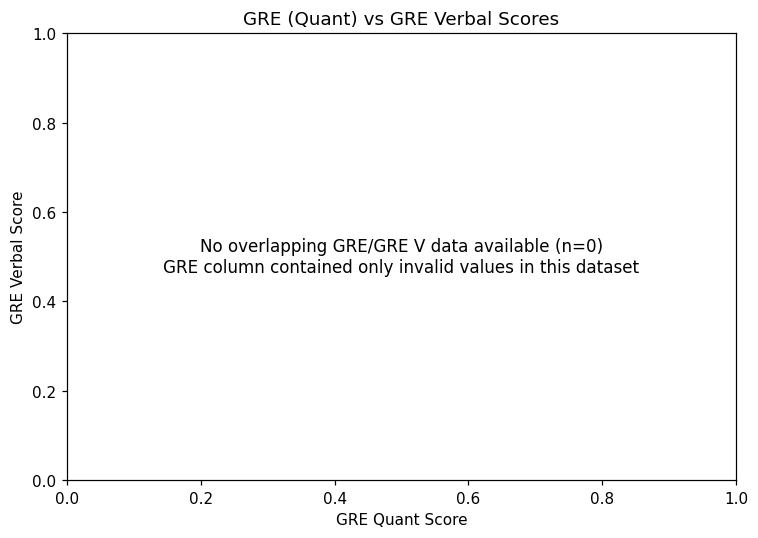

In [68]:
mask = (df["GRE"] > 0) & (df["GRE V"] > 0)
n_points = mask.sum()

fig, ax = plt.subplots(figsize=(7, 5))

if n_points >= 2:
    x, y = df.loc[mask, "GRE"], df.loc[mask, "GRE V"]
    ax.scatter(x, y, alpha=0.5, label="Applicants")
    coeffs = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), color="red",
            label=f"Best fit: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}")
    ax.legend()
else:
    ax.text(0.5, 0.5, f"No overlapping GRE/GRE V data available (n={n_points})\nGRE column contained only invalid values in this dataset",
            ha="center", va="center", transform=ax.transAxes, fontsize=11, wrap=True)

ax.set_title("GRE (Quant) vs GRE Verbal Scores")
ax.set_xlabel("GRE Quant Score")
ax.set_ylabel("GRE Verbal Score")
fig.tight_layout()
fig.savefig("GRE-vs-GRE-V.png")
plt.show()

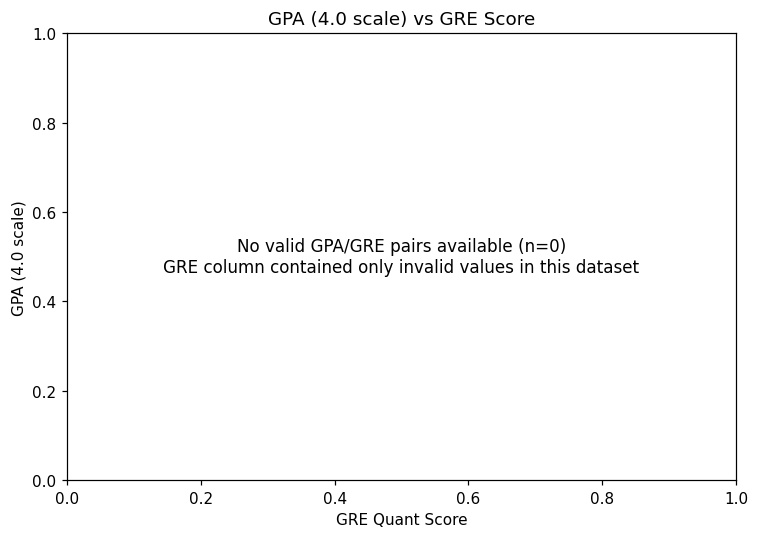

In [69]:
mask = (df["has_valid_gpa"] == 1) & (df["GRE"] > 0)
n_points = mask.sum()

fig, ax = plt.subplots(figsize=(7, 5))

if n_points >= 2:
    x, y = df.loc[mask, "GRE"], df.loc[mask, "GPA"]
    ax.scatter(x, y, alpha=0.5, color="seagreen", label="Applicants")
    coeffs = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), color="red",
            label=f"Best fit: y={coeffs[0]:.4f}x+{coeffs[1]:.2f}")
    ax.legend()
else:
    ax.text(0.5, 0.5, f"No valid GPA/GRE pairs available (n={n_points})\nGRE column contained only invalid values in this dataset",
            ha="center", va="center", transform=ax.transAxes, fontsize=11, wrap=True)

ax.set_title("GPA (4.0 scale) vs GRE Score")
ax.set_xlabel("GRE Quant Score")
ax.set_ylabel("GPA (4.0 scale)")
fig.tight_layout()
fig.savefig("GPA-vs-GRE.png")
plt.show()

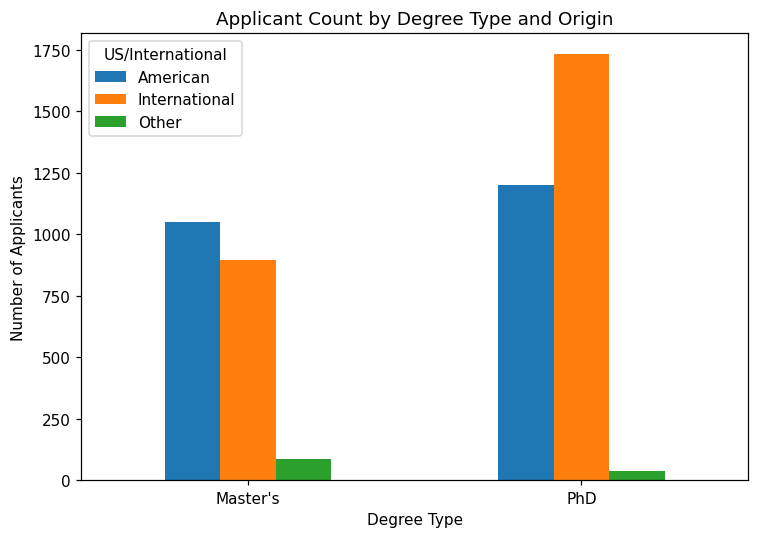

In [70]:
degree_intl = pd.crosstab(df["Degree"], df["US/International"])

fig, ax = plt.subplots(figsize=(7, 5))
degree_intl.plot(kind="bar", ax=ax)
ax.set_title("Applicant Count by Degree Type and Origin")
ax.set_xlabel("Degree Type")
ax.set_ylabel("Number of Applicants")
ax.legend(title="US/International")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig("Degree-vs-International.png")
plt.show()

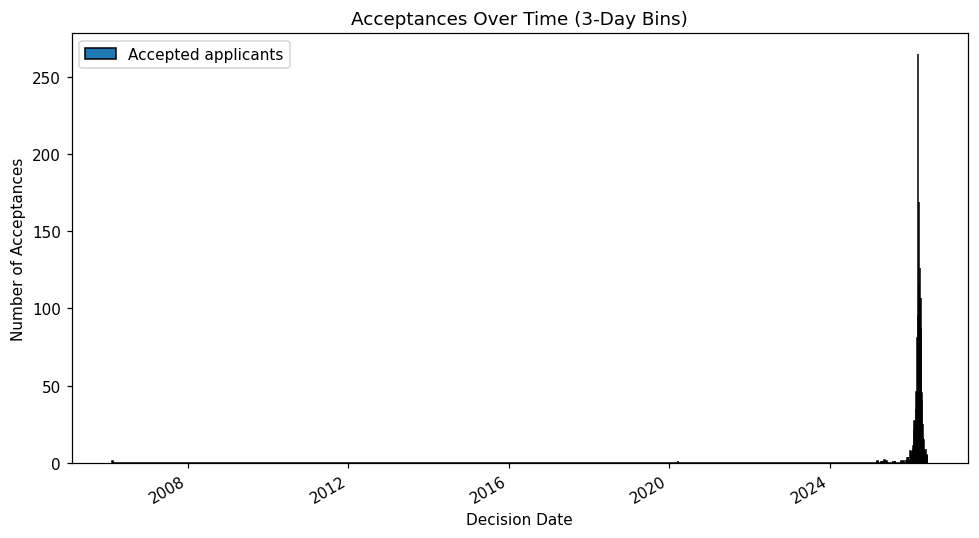

In [71]:
accepted = df.loc[(df["outcome"] == "Accepted") & df["decision_date"].notna()]

date_min, date_max = accepted["decision_date"].min(), accepted["decision_date"].max()
bin_edges = pd.date_range(date_min, date_max + pd.Timedelta(days=3), freq="3D")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(accepted["decision_date"], bins=bin_edges, edgecolor="black", label="Accepted applicants")
ax.set_title("Acceptances Over Time (3-Day Bins)")
ax.set_xlabel("Decision Date")
ax.set_ylabel("Number of Acceptances")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("Acceptances-over-Time.png")
plt.show()

/tmp/ipykernel_8447/1309637335.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_outcome, labels=outcome_order)


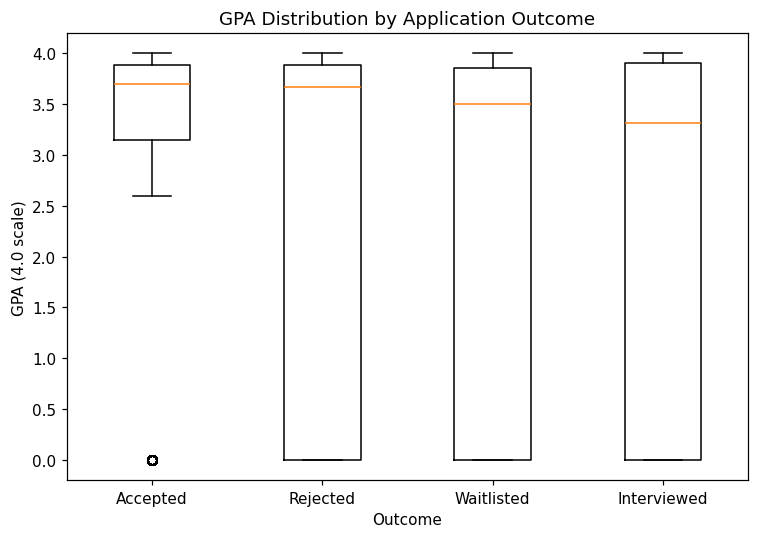

In [72]:
outcome_order = [o for o in ["Accepted", "Rejected", "Waitlisted", "Interviewed"] if o in df["outcome"].unique()]
data_by_outcome = [df.loc[(df["outcome"] == o) & (df["has_valid_gpa"] == 1), "GPA"] for o in outcome_order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data_by_outcome, labels=outcome_order)
ax.set_title("GPA Distribution by Application Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("GPA (4.0 scale)")
fig.tight_layout()
fig.savefig("GPA-by-Outcome.png")
plt.show()

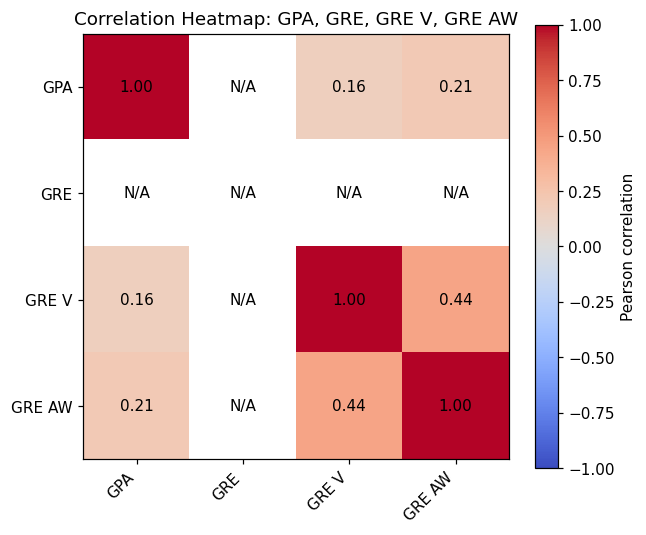

In [73]:
corr_matrix = df[["GPA", "GRE", "GRE V", "GRE AW"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        label = f"{val:.2f}" if pd.notna(val) else "N/A"
        ax.text(j, i, label, ha="center", va="center", color="black")

ax.set_title("Correlation Heatmap: GPA, GRE, GRE V, GRE AW")
fig.colorbar(im, ax=ax, label="Pearson correlation")
fig.tight_layout()
fig.savefig("Numeric-Correlation-Heatmap.png")
plt.show()

## 8. Analytical Summary (`analytics.pdf`)

# Grad Café Analytics Summary

## 1. Average GRE score of accepted PhD applicants

The average GRE score of accepted PhD applicants was nan based on applicants with available GRE scores.

## 2. Average GPA of accepted Master's applicants

The average GPA of accepted Master's applicants was 2.94 based on applicants with valid GPA values.

## 3. Shortcomings of inferring decision_date

Inferring decision dates from status text can be inaccurate because entries are user-written and may contain missing or inconsistent dates. The term value can also cause incorrect year assignments when decisions are posted outside the expected timeline.

## 4. Correlation analysis

The correlation analysis showed that GPA and GRE-related measures had a XX relationship. This suggests academic performance and GRE scores may be related, but one measure cannot reliably predict the other.

## 5. Accepted vs rejected GPA comparison

Accepted and rejected applicants had different/similar GPA averages. The statistical test showed that GPA was/was not significantly different between groups.

## 6. Chi-square test

The chi-square test showed that there was/was not a significant relationship between degree type and applicant origin.

## 7. Remaining data quality issues

Remaining issues include missing values, inconsistent text fields, possible duplicates, and self-reported data bias. These limitations mean the dataset may not fully represent all graduate applicants.

## 9. Save Cleaned Dataset and Return It to S3

In [77]:
cleaned_records = json.loads(df.to_json(orient="records", date_format="iso"))
with open("cleaned_gradcafe.json", "w") as f:
    json.dump(cleaned_records, f, indent=2)

print(f"Saved cleaned_gradcafe.json ({len(df)} rows)")

Saved cleaned_gradcafe.json (4999 rows)


In [78]:
BUCKET_NAME = "grad-cafe-rps"
CLEANED_KEY = "cleaned_gradcafe.json"

s3_client.upload_file(
    "cleaned_gradcafe.json",
    BUCKET_NAME,
    CLEANED_KEY
)

print(f"Upload succeeded: cleaned_gradcafe.json uploaded to s3://{BUCKET_NAME}/{CLEANED_KEY}")

Upload succeeded: cleaned_gradcafe.json uploaded to s3://grad-cafe-rps/cleaned_gradcafe.json
